# Drug Review Sentiment Classification using TF-IDF and LinearSVC

This notebook builds a sentiment classifier using the UCI/Kaggle drug review dataset. The review text is used as input and the sentiment label is created from numeric rating. The aim is to test a basic NLP pipeline that can later compared with transformer-based model such as BioBert and finally integrate with the UI.

## Technique Selection and Justification

This model uses several basic NLP techniques: text normalization, tokenization, TF-IDF feature extraction, n-grams and LinearSVC classification. Normalization reduce noise in the text, while tokenization prepares the reviews for vectorization. 

TF-IDF is used because it represents how important words or phrases are within the review dataset. I used both unigrams and bigrams so the model can learn from individual words as well as short phrases. Stopword removal was not used because words such as "not", "no" and "never" are important for sentiment. 


In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
import html
import re
import os
from pathlib import Path
import joblib
import nltk
from typing import Callable, Any
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

## Dataset and Label Construction

The dataset is loaded using the original training and testing files. The rating distribution is checked first because the sentiment labels are derived from the rating column. 

Ratings from 1 to 4 are mapped to NEGATIVE, ratings from 5 to 6 are mapped to NEUTRAL, and ratings from 7 to 10 are mapped to POSITIVE. After this mapping the class distribution is still imbalanced with POSITIVE being the largest class and NEUTRAL being the smallest class. 


In [2]:
dataset_path = kagglehub.dataset_download('jessicali9530/kuc-hackathon-winter-2018')
drugs_train  = pd.read_csv(os.path.join(dataset_path, 'drugsComTrain_raw.csv'), encoding = 'utf-8')
drugs_test   = pd.read_csv(os.path.join(dataset_path, 'drugsComTest_raw.csv'),  encoding = 'utf-8')

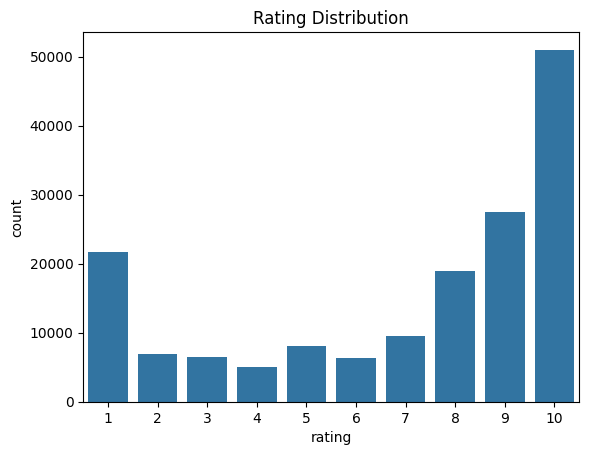

In [3]:
sns.countplot(data=drugs_train, x="rating")
plt.title("Rating Distribution")
plt.show()

In [4]:
SENTIMENT_LABEL_MAP = {
    0: 'NEGATIVE',
    1: 'NEUTRAL',
    2: 'POSITIVE'
}

def rating_to_label(rating):
    rating = int(rating)
    if 1 <= rating <= 4:
        return 0 #NEGATIVE
    elif 5 <= rating <= 6:
        return 1 # NEUTRAL 
    else:
        return 2 # POSITIVE

drugs_train['sentiment'] = drugs_train['rating'].map(rating_to_label)
drugs_test['sentiment'] = drugs_test['rating'].map(rating_to_label)

print(drugs_train["sentiment"].map(SENTIMENT_LABEL_MAP).value_counts())
print(drugs_test["sentiment"].map(SENTIMENT_LABEL_MAP).value_counts())

sentiment
POSITIVE    106866
NEGATIVE     40075
NEUTRAL      14356
Name: count, dtype: int64
sentiment
POSITIVE    35440
NEGATIVE    13497
NEUTRAL      4829
Name: count, dtype: int64


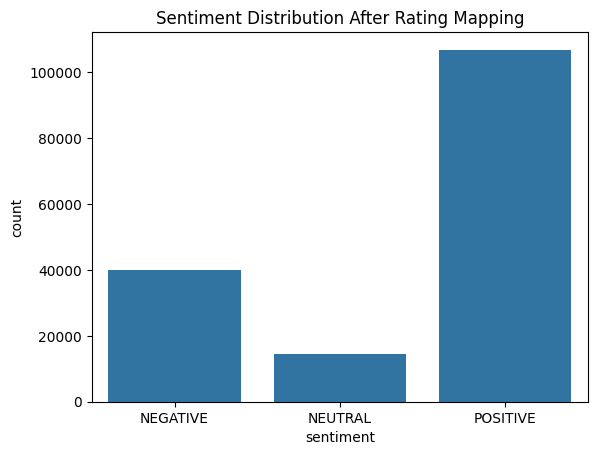

In [5]:
sns.countplot(
    x=drugs_train["sentiment"].map(SENTIMENT_LABEL_MAP),
    order=["NEGATIVE", "NEUTRAL", "POSITIVE"]
)
plt.title("Sentiment Distribution After Rating Mapping")
plt.show()

In the training set, there are 106,866 Positive reviews, 40,075 Negaative reviews and 14.356 Neutral reviews. This imbalance is handled later using class weighting in the classifier. 

In [6]:
drugs_train[["review", "rating", "sentiment"]].head()

,review,rating,sentiment
0,"""It has no side effect, I take it in combinati...",9,2
1,"""My son is halfway through his fourth week of ...",8,2
2,"""I used to take another oral contraceptive, wh...",5,1
3,"""This is my first time using any form of birth...",8,2
4,"""Suboxone has completely turned my life around...",9,2


## Preprocessing and Feature Extraction

The preprocessing function decodes HTML entities, normalizes Unicode, lowercases the text, removes URLs and HTML tags, and normalizes extra whitespace. This keeps preprocessing simple while removing common noise in the reviews. 

THe processed text is converted into TF-IDF features using unigrams and bigrams with 'ngram_range=(1,2)'. Stopwords are kept because negation words can change the sentiment meaning of a phrase or sentences.


In [7]:
def normalize_text(text: str) -> str:
    text = html.unescape(text)
    text = unidecode(text)

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)

    # text = re.sub(r"[^a-z0-9\s'\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

class TextPreprocessor:
    transformations: list[Callable]

    def __init__(self) -> None:
        self.transformations = []

    def add(self, tfomer: Callable):
        self.transformations.append(tfomer)
        return self

    def __call__(self, sample: str) -> Any:
        for tform in self.transformations:
            sample = tform(sample)
        return sample

In [8]:
preprocessor = TextPreprocessor() \
    .add(normalize_text) \
    .add(nltk.word_tokenize) \

vectorizer_tfidf = TfidfVectorizer(
    lowercase     = False, # Handled in normalize_text
    tokenizer     = preprocessor,

    stop_words    = None, # Keep stopwords such as "not","no",and "never"
    ngram_range   = (1, 2),
    token_pattern = None, 

    min_df       = 2,
    max_df       = 0.95,
    sublinear_tf = True
)

In [9]:
train_tfidf = vectorizer_tfidf.fit_transform(drugs_train['review'])
test_tfidf  = vectorizer_tfidf.transform(drugs_test['review'])

## Model Training

A LinearSVC model is trained using TF-IDF features, LinearSVC is suitable for this task because it works well with sparse high-dimensional text features. The model uses 'class_weight = "balanced"' to reduce the effect of class imbalance. This gives more importance to minority classes such as NEUTRAL during training. 

In [10]:
clf_svc = LinearSVC(class_weight = 'balanced')
clf_svc.fit(X = train_tfidf, y = drugs_train['sentiment'].to_list())

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


## Evaluation and Analysis

The model is evaluated using precision, recall, F1-score, accuracy and a confusion matrix. Accuracy shows the overall performance while macro F1 is useful because the classes are imbalanced. 

The model achieved around 0.92 accuracy and 0.86 macro F1 on the test set. POSITIVE and NEGATIVE reviews were classified strongly while NEUTRAL had the lowest recall around 0.67


In [11]:
test_pred = clf_svc.predict(X = test_tfidf)
ticklabels = list(map(lambda lb : lb[1], sorted(SENTIMENT_LABEL_MAP.items(), key = lambda lb : lb[0])))

print(classification_report(
    drugs_test['sentiment'].to_list(),
    test_pred,
    target_names = ticklabels
))


              precision    recall  f1-score   support

    NEGATIVE       0.87      0.91      0.89     13497
     NEUTRAL       0.80      0.67      0.73      4829
    POSITIVE       0.95      0.95      0.95     35440

    accuracy                           0.92     53766
   macro avg       0.87      0.84      0.86     53766
weighted avg       0.92      0.92      0.92     53766



                 Predicted NEGATIVE  Predicted NEUTRAL  Predicted POSITIVE
Actual NEGATIVE               12229                312                 956
Actual NEUTRAL                  691               3218                 920
Actual POSITIVE                1114                494               33832

Per-class recall:
Actual NEGATIVE    0.906
Actual NEUTRAL     0.666
Actual POSITIVE    0.955
dtype: float64


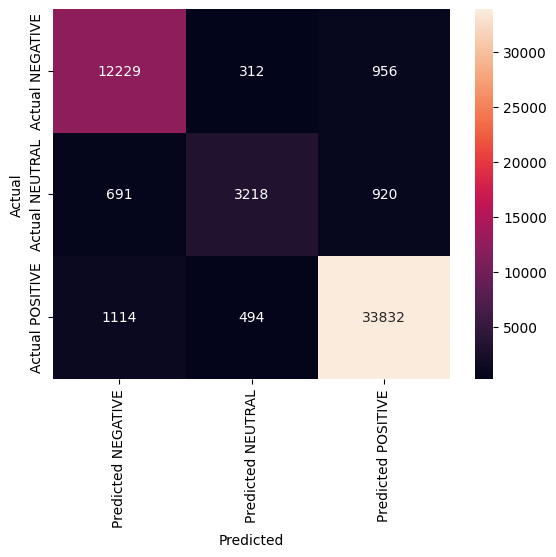

In [12]:
conf_mat = confusion_matrix(y_true = drugs_test['sentiment'].to_numpy(), y_pred = test_pred)
ticklabels = list(map(lambda lb : lb[1], sorted(SENTIMENT_LABEL_MAP.items(), key = lambda lb : lb[0])))

conf_mat_df = pd.DataFrame(
    conf_mat,
    index = [f'Actual {label}' for label in ticklabels],
    columns = [f'Predicted {label}' for label in ticklabels]
)

print(conf_mat_df)
print()
print('Per-class recall:')
print((conf_mat_df.to_numpy().diagonal() / conf_mat_df.sum(axis = 1)).round(3))

sns.heatmap(conf_mat_df, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


From the confusion matrix, the model correctly classified 3,218 out of 4,829 NEUTRAL reviews. The remaining NEUTRAL reviews mostly confused with POSITIVE and NEUTRAL reviews which make sense because neutral reviews can contain mixed opinions. 

## Example Predictions

The example predictions are used as a simple sanity check. The model correctly predicts a positive sentence as POSITIVE and negated sentence as NEGATIVE. This suggest that keeping negation words during preprocessing was useful. 


In [13]:
ipred = clf_svc.predict(X = vectorizer_tfidf.transform(['This medicine helped cure my throat problem.']))
SENTIMENT_LABEL_MAP[int(ipred[0])]

'POSITIVE'

In [14]:
ipred = clf_svc.predict(X = vectorizer_tfidf.transform(['This medicine did not help curing my throat problem.']))
SENTIMENT_LABEL_MAP[int(ipred[0])]

'NEGATIVE'

## Serialize Objects

Put the necessary objects in dictionary for exporting

In [15]:
save_object = {
    'classes':    ['NEGATIVE', 'NEUTRAL', 'POSITIVE'],
    'vectorizer': vectorizer_tfidf,
    'classifier': clf_svc
}

save_object

{'classes': ['NEGATIVE', 'NEUTRAL', 'POSITIVE'],
 'vectorizer': TfidfVectorizer(lowercase=False, max_df=0.95, min_df=2, ngram_range=(1, 2),
                 sublinear_tf=True, token_pattern=None,
                 tokenizer=<__main__.TextPreprocessor object at 0x00000116CD711D30>),
 'classifier': LinearSVC(class_weight='balanced')}

## Save the Classifier Suite

export the classifier and vectorizer as serialized joblib object so that the streamlit application can load it.

In [16]:
ROOT_DIR = Path(os.path.abspath('')).resolve().parent
APP_DIR = ROOT_DIR / 'web_app-integrated'

joblib.dump(save_object, str(APP_DIR / 'sentiment_classifier_objects.joblib'))

['D:\\Academic\\AdvNLP\\Project\\GitHub\\COMP8420-Group-L-Healthcare\\web_app-integrated\\sentiment_classifier_objects.joblib']

## Result Summary

Overall, the TF-IDF + Linear SVC model performs well on this sentiment classification task . It achieves strong accuracy and macro F1 while remaining simple and efficient. 

The main limitation is in NEUTRAL class, which is harder to predict because it as fewe examples and often contains mixed sentiment. Compared with BioBERT experiment, this model performs better and is easier to deploy, so it is the stronger candidate for the final UI. 

For comparison, a BioBERT model was tested in 'drugs-sentiment_bioBert.ipynb' The TF-IDF + LinearSVC model in this notebook achieved accuracy of 0.92 and 0.86 macro F1 on the full test set while BioBERT achieved 0.72 accuracy and 0.61 macro F1. 

The largest difference was in the NEUTRAL class. LinearSVC achieved 0.73 F1 for Neutral but BioBERT only achieved 0.26 F1. Altough BioBERT is more advanced model the simpler TF-IDF + LinearSVC performed better for this sentiment analysis. 


| Model | Notebook | Test setup | Accuracy | Macro F1 | Neutral F1 |
|---|---|---:|---:|---:|---:|
| TF-IDF + LinearSVC | `drugs-review-sentiment.ipynb` | Full test set, 53,766 reviews | 0.92 | 0.86 | 0.73 |
| BioBERT | `drugs-sentiment_bioBert.ipynb` | Sampled test set, 5,000 reviews | 0.72 | 0.61 | 0.26 |